## Objective

This notebook extends the historical analysis by examining how the Aggressive Growth, Balanced Growth, and Resilient Growth portfolios may respond to hypothetical market shocks.

The analysis combines three approaches. Hypothetical stress testing evaluates portfolio losses under defined economic scenarios. Risk-factor sensitivity analysis examines exposure to equity markets, interest rates, credit spreads, currencies, and commodities. Reverse stress testing works backward from specified portfolio-loss thresholds to identify the market conditions that could produce those outcomes.

Together, these approaches provide a broader understanding of portfolio vulnerabilities and the trade-offs associated with different strategic asset allocations.

## Methodology

The hypothetical scenarios assign assumed cumulative returns to each ETF over an illustrative market stress episode. Portfolio-level results are calculated by multiplying each asset's assumed return by its strategic weight and adding the contributions across the portfolio.

For portfolio $p$:

$$
R_p^{\text{stress}}=\sum_{i=1}^{n}w_{p,i}s_i
$$

where:

- $R_p^{\text{stress}}$ is the estimated portfolio return under the scenario.
- $w_{p,i}$ is the strategic weight assigned to asset $i$.
- $s_i$ is the assumed return shock for asset $i$.

The calculation applies the starting strategic weights to the full set of assumed asset returns. It does not model the timing of individual market movements, portfolio rebalancing during the stress episode, or transaction costs.

The assumed shocks are illustrative stress-test inputs rather than forecasts or probability estimates. Their purpose is to examine portfolio exposures under different adverse market conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load portfolio returns created in Notebook 2
portfolio_returns = pd.read_csv(
    "portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

# Load daily ETF returns created in Notebook 1
returns = pd.read_csv(
    "returns_daily.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
portfolio_weights = pd.read_csv(
    "portfolio_weights.csv",
    index_col=0
)

portfolio_weights.style.format("{:.0%}")


,Aggressive,Balanced,Resilient
VTI,55%,40%,25%
VEU,20%,15%,10%
VWO,10%,10%,5%
BND,5%,25%,45%
GLD,5%,5%,10%
BIL,5%,5%,5%


In [4]:
portfolio_weights.sum()

Aggressive    1.0
Balanced      1.0
Resilient     1.0
dtype: float64

## Part I — Hypothetical Stress Testing
### Scenario 1 — Severe Global Recession

This scenario assumes a synchronized global recession accompanied by declining corporate earnings, heightened risk aversion, and substantial losses across equity markets.

Emerging-market equities are assigned the largest negative shock, while bonds and gold are assumed to provide some protection. Short-term Treasury bills remain relatively stable.

The scenario is designed to examine how the portfolios respond to a broad equity-led contraction and how their defensive allocations affect the resulting losses.

The assumptions are informed by the direction and relative severity of institutional recession stress scenarios, but the ETF-level shocks are constructed specifically for this project rather than reproduced from a supervisory stress test.

In [5]:
# Severe Global Recession scenario assumptions

recession_assumptions = pd.DataFrame({
    "Market Exposure": [
        "U.S. Equity",
        "International Equity",
        "Emerging Markets",
        "U.S. Bonds",
        "Gold",
        "Short-Term Treasuries"
    ],
    
    "Shock": [
        -0.45,
        -0.40,
        -0.50,
         0.03,
         0.08,
         0.01
    ],
    
    "Rationale": [
        "Severe earnings contraction and risk-off equity repricing",
        "Global recession and developed-market weakness",
        "Greater vulnerability to global risk aversion and capital stress",
        "Falling risk-free rates provide support, partially offset by wider credit spreads",
        "Assumed safe-haven demand during severe financial stress",
        "Limited price sensitivity and flight-to-safety support"
    ]
},
index=[
    "VTI",
    "VEU",
    "VWO",
    "BND",
    "GLD",
    "BIL"
])

#Make exposure a regular column for display 
recession_assumptions.index.name = "Exposure"

recession_assumptions = recession_assumptions.reset_index()

#Display assumptions table
recession_assumptions.style.hide(axis="index").format({
    "Shock": "{:.0%}"
})

Exposure,Market Exposure,Shock,Rationale
VTI,U.S. Equity,-45%,Severe earnings contraction and risk-off equity repricing
VEU,International Equity,-40%,Global recession and developed-market weakness
VWO,Emerging Markets,-50%,Greater vulnerability to global risk aversion and capital stress
BND,U.S. Bonds,3%,"Falling risk-free rates provide support, partially offset by wider credit spreads"
GLD,Gold,8%,Assumed safe-haven demand during severe financial stress
BIL,Short-Term Treasuries,1%,Limited price sensitivity and flight-to-safety support


In [6]:
# Extract shock values for calculations
recession_shocks = recession_assumptions.set_index(
    "Exposure"
)["Shock"]

# Calculate portfolio return under Severe Global Recession
recession_portfolio_returns = (
    portfolio_weights
    .mul(recession_shocks, axis=0)
    .sum()
)

In [7]:
# Create scenario results table
recession_results = pd.DataFrame({
    "Scenario Return": recession_portfolio_returns,
    "Ending Value of $100": 100 * (1 + recession_portfolio_returns)
})

# Make portfolio names a regular column
recession_results.index.name = "Portfolio"
recession_results = recession_results.reset_index()

# Display results
recession_results.style.hide(axis="index").format({
    "Scenario Return": "{:.2%}",
    "Ending Value of $100": "${:.2f}"
})

Portfolio,Scenario Return,Ending Value of $100
Aggressive,-37.15%,$62.85
Balanced,-27.80%,$72.20
Resilient,-15.55%,$84.45


In [8]:
# Contribution of each exposure to portfolio scenario return
recession_contributions = portfolio_weights.mul(
    recession_shocks,
    axis=0
)

recession_contributions.style.format("{:.2%}")

Portfolio,Aggressive,Balanced,Resilient
VTI,-24.75%,-18.00%,-11.25%
VEU,-8.00%,-6.00%,-4.00%
VWO,-5.00%,-5.00%,-2.50%
BND,0.15%,0.75%,1.35%
GLD,0.40%,0.40%,0.80%
BIL,0.05%,0.05%,0.05%


### Interpretation

The Severe Global Recession scenario produces the largest estimated loss for Aggressive Growth and the smallest for Resilient Growth.

The contribution analysis shows that equity exposure accounts for most of the losses, particularly VTI because of its relatively large allocation in each portfolio. International and emerging-market equities add further downside exposure, while bonds, gold, and short-term Treasury bills partially offset those losses under the assumed conditions.

Resilient Growth benefits most from the positive bond and gold shocks because of its larger allocations to those assets. The results illustrate how the portfolios' strategic weights influence their exposure to an equity-led recession, although the estimated losses remain conditional on the scenario assumptions.

### Scenario 2 — Geopolitical Conflict & Energy Supply Disruption
### Scenario Description
This scenario considers a severe geopolitical conflict that results in a significant disruption to global energy supplies and international trade. Reduced availability of crude oil and other energy resources is assumed to produce a sharp increase in energy prices, contributing to higher inflation expectations and tighter financial conditions. Global equity markets decline as economic growth expectations weaken and uncertainty increases, with international and emerging-market equities experiencing greater stress because of their exposure to global trade and capital flows. Rising inflation and interest rates place downward pressure on fixed-income assets, while gold benefits from increased safe-haven demand and short-term Treasury bills remain relatively stable.

The scenario evaluates each portfolio's vulnerability to a geopolitical and inflationary supply shock and examines the effectiveness of diversification when both equity and fixed-income assets experience losses simultaneously. Particular attention is given to whether allocations to gold and short-term Treasury bills provide sufficient defensive support when traditional stock-bond diversification becomes less effective.

### Scenario Assumptions
The following shocks represent assumed market responses to a severe geopolitical conflict and energy-supply disruption and are intended as stress-test inputs rather than forecasts. The scenario assumes broad declines across global equity markets as higher energy costs, increased uncertainty, and weaker economic growth expectations reduce investor risk appetite. International and emerging-market equities are assumed to experience greater stress because of their sensitivity to global trade disruptions and capital flows.

Unlike the Severe Global Recession scenario, fixed-income assets are assumed to experience losses as higher inflation expectations and interest rates place upward pressure on bond yields. Gold is assumed to benefit from increased safe-haven demand, while short-term Treasury bills remain comparatively stable because of their limited interest-rate sensitivity.

### Scenario Design Reference
Scenario assumptions are informed by the Federal Reserve's 2026 Global Market Shock, which considers a market environment characterized by persistently high inflation expectations, higher commodity prices, rising Treasury rates, declining global equity prices, widening credit spreads, and U.S. dollar appreciation. 

Because the Federal Reserve scenario specifies shocks to individual market risk factors rather than the ETFs used in this analysis, the institutional scenario is used as a directional and severity reference rather than replicated directly. ETF-level shocks are constructed to reflect the relative sensitivity of each portfolio exposure to the assumed geopolitical, inflation, interest-rate, and risk-aversion shocks.

In [9]:
# Geopolitical Conflict & Energy Supply Disruption scenario assumptions
geopolitical_assumptions = pd.DataFrame({
    "Market Exposure": [
        "U.S. Equity",
        "International Equity",
        "Emerging Markets",
        "U.S. Bonds",
        "Gold",
        "Short-Term Treasuries"
    ],
    
    "Shock": [
        -0.25,
        -0.30,
        -0.35,
        -0.08,
         0.15,
         0.00
    ],
    
    "Rationale": [
        "Risk-off repricing, weaker growth expectations, and higher discount rates",
        "Greater exposure to global trade disruption and imported-energy pressures",
        "Greater sensitivity to global risk aversion, dollar strength, and capital outflows",
        "Higher inflation and yields combined with widening corporate credit spreads",
        "Safe-haven demand and higher inflation expectations support gold prices",
        "Very short duration limits price sensitivity during the interest-rate shock"
    ]
},
index=[
    "VTI",
    "VEU",
    "VWO",
    "BND",
    "GLD",
    "BIL"
])


# Make Exposure a regular column for display
geopolitical_assumptions.index.name = "Exposure"

geopolitical_assumptions = geopolitical_assumptions.reset_index()

# Display assumptions table
geopolitical_assumptions.style.hide(axis="index").format({
    "Shock": "{:.0%}"
})

Exposure,Market Exposure,Shock,Rationale
VTI,U.S. Equity,-25%,"Risk-off repricing, weaker growth expectations, and higher discount rates"
VEU,International Equity,-30%,Greater exposure to global trade disruption and imported-energy pressures
VWO,Emerging Markets,-35%,"Greater sensitivity to global risk aversion, dollar strength, and capital outflows"
BND,U.S. Bonds,-8%,Higher inflation and yields combined with widening corporate credit spreads
GLD,Gold,15%,Safe-haven demand and higher inflation expectations support gold prices
BIL,Short-Term Treasuries,0%,Very short duration limits price sensitivity during the interest-rate shock


In [10]:
# Extract shock values for calculations
geopolitical_shocks = geopolitical_assumptions.set_index(
    "Exposure"
)["Shock"]

# Calculate portfolio returns under the
# Geopolitical Conflict & Energy Supply Disruption scenario
geopolitical_portfolio_returns = (
    portfolio_weights
    .mul(geopolitical_shocks, axis=0)
    .sum()
)

In [11]:
# Create scenario results table
geopolitical_results = pd.DataFrame({
    "Scenario Return": geopolitical_portfolio_returns,
    "Ending Value of $100": 100 * (
        1 + geopolitical_portfolio_returns
    )
})

# Make portfolio names a regular column
geopolitical_results.index.name = "Portfolio"
geopolitical_results = geopolitical_results.reset_index()

# Display results
geopolitical_results.style.hide(axis="index").format({
    "Scenario Return": "{:.2%}",
    "Ending Value of $100": "${:.2f}"
})

Portfolio,Scenario Return,Ending Value of $100
Aggressive,-22.90%,$77.10
Balanced,-19.25%,$80.75
Resilient,-13.10%,$86.90


In [12]:
# Contribution of each exposure to portfolio scenario return
geopolitical_contributions = portfolio_weights.mul(
    geopolitical_shocks,
    axis=0
)

geopolitical_contributions.style.format("{:.2%}")

Portfolio,Aggressive,Balanced,Resilient
VTI,-13.75%,-10.00%,-6.25%
VEU,-6.00%,-4.50%,-3.00%
VWO,-3.50%,-3.50%,-1.75%
BND,-0.40%,-2.00%,-3.60%
GLD,0.75%,0.75%,1.50%
BIL,0.00%,0.00%,0.00%


### Interpretation

The geopolitical and energy-supply scenario produces losses across all three portfolios, with Aggressive Growth experiencing the largest decline and Resilient Growth the smallest.

Unlike the recession scenario, BND contributes negatively because the assumed inflation and interest-rate shock places pressure on bond prices. This is particularly relevant to Resilient Growth, where the larger BND allocation creates a greater negative contribution.

Gold partially offsets the losses, with the largest positive contribution occurring in Resilient Growth. The results show that reducing equity exposure continues to provide some protection under the assumed conditions, but the benefit of the defensive allocation is reduced when bonds and equities decline together.

### Scenario 3 — Severe Stagflation
### Scenario Description
This scenario considers a severe stagflationary environment characterized by persistently high inflation, weak or negative economic growth, elevated interest rates, and declining corporate profitability. Equity markets are assumed to experience losses as higher input costs, weaker consumer demand, and elevated discount rates place pressure on earnings and valuations. Fixed-income assets also experience losses as persistent inflation and higher interest rates increase bond yields and reduce bond prices. Gold is assumed to benefit from inflation concerns and demand for alternative stores of value, while short-term Treasury bills remain comparatively stable because of their limited duration and ability to adjust more quickly to higher interest rates.

### Purpose
The scenario evaluates each portfolio's vulnerability to a prolonged environment in which inflation remains elevated while economic growth deteriorates. Unlike a conventional recession, where declining interest rates may allow bonds to offset equity losses, stagflation can weaken the traditional diversification benefit between stocks and bonds. The scenario therefore examines whether differences in equity exposure, bond allocation, gold holdings, and short-term Treasury exposure materially affect portfolio resilience under persistent inflationary and growth pressures.

### Scenario Assumptions
The following shocks represent assumed market responses under a severe stagflationary environment and are intended as stress-test inputs rather than forecasts. Equity exposures receive negative shocks reflecting weaker economic growth, declining corporate profitability, and elevated discount rates. Emerging-market equities are assumed to experience greater losses because of their sensitivity to global financial conditions, capital flows, currency pressures, and higher input costs.

Broad U.S. bonds are also assumed to decline as persistent inflation keeps interest rates and bond yields elevated, limiting the defensive benefit normally associated with fixed-income exposure during economic weakness. Gold receives a positive shock because of its potential role as an inflation-sensitive and defensive asset, while short-term Treasury bills remain comparatively stable.

### Scenario Calibration
The scenario is informed by institutional stress-testing frameworks, including Federal Reserve and Bank of England stress scenarios, that examine combinations of persistent inflation, elevated interest rates, weak economic activity, declining asset prices, and tighter financial conditions. Because these institutional scenarios specify shocks to macroeconomic and market risk factors rather than the ETFs examined in this analysis, they are used as directional and severity references rather than replicated directly. ETF-level shocks are constructed to reflect the expected relative sensitivity of each portfolio exposure to a prolonged stagflationary environment.

In [13]:
# Severe Stagflation scenario assumptions
stagflation_assumptions = pd.DataFrame({
    "Market Exposure": [
        "U.S. Equity",
        "International Equity",
        "Emerging Markets",
        "U.S. Bonds",
        "Gold",
        "Short-Term Treasuries"
    ],
    
    "Shock": [
        -0.30,
        -0.32,
        -0.38,
        -0.12,
         0.20,
         0.02
    ],
    
    "Rationale": [
        "Weak growth, margin pressure, and persistently elevated discount rates",
        "Weak global growth combined with inflation and trade sensitivity",
        "Greater sensitivity to dollar strength, capital outflows, and inflation",
        "Persistent inflation and elevated yields produce significant duration losses",
        "Inflation concerns and defensive demand support gold prices",
        "Low duration and higher short-term yields provide modest support"
    ]
},
index=[
    "VTI",
    "VEU",
    "VWO",
    "BND",
    "GLD",
    "BIL"
])

# Make Exposure a regular column for display
stagflation_assumptions.index.name = "Exposure"

stagflation_assumptions = stagflation_assumptions.reset_index()

# Display assumptions table
stagflation_assumptions.style.hide(axis="index").format({
    "Shock": "{:.0%}"
})

Exposure,Market Exposure,Shock,Rationale
VTI,U.S. Equity,-30%,"Weak growth, margin pressure, and persistently elevated discount rates"
VEU,International Equity,-32%,Weak global growth combined with inflation and trade sensitivity
VWO,Emerging Markets,-38%,"Greater sensitivity to dollar strength, capital outflows, and inflation"
BND,U.S. Bonds,-12%,Persistent inflation and elevated yields produce significant duration losses
GLD,Gold,20%,Inflation concerns and defensive demand support gold prices
BIL,Short-Term Treasuries,2%,Low duration and higher short-term yields provide modest support


In [14]:
# Extract shock values for calculations
stagflation_shocks = stagflation_assumptions.set_index(
    "Exposure"
)["Shock"]

# Calculate portfolio returns under the Severe Stagflation scenario
stagflation_portfolio_returns = (
    portfolio_weights
    .mul(stagflation_shocks, axis=0)
    .sum()
)

In [15]:
# Create scenario results table
stagflation_results = pd.DataFrame({
    "Scenario Return": stagflation_portfolio_returns,
    "Ending Value of $100": 100 * (
        1 + stagflation_portfolio_returns
    )
})

# Make portfolio names a regular column
stagflation_results.index.name = "Portfolio"
stagflation_results = stagflation_results.reset_index()

# Display results
stagflation_results.style.hide(axis="index").format({
    "Scenario Return": "{:.2%}",
    "Ending Value of $100": "${:.2f}"
})

Portfolio,Scenario Return,Ending Value of $100
Aggressive,-26.20%,$73.80
Balanced,-22.50%,$77.50
Resilient,-15.90%,$84.10


In [16]:
# Contribution of each exposure to portfolio scenario return
stagflation_contributions = portfolio_weights.mul(
    stagflation_shocks,
    axis=0
)

stagflation_contributions.style.format("{:.2%}")

Portfolio,Aggressive,Balanced,Resilient
VTI,-16.50%,-12.00%,-7.50%
VEU,-6.40%,-4.80%,-3.20%
VWO,-3.80%,-3.80%,-1.90%
BND,-0.60%,-3.00%,-5.40%
GLD,1.00%,1.00%,2.00%
BIL,0.10%,0.10%,0.10%


### Interpretation

The Severe Stagflation scenario produces losses across all three portfolios as weak growth and persistent inflation place simultaneous pressure on equities and bonds.

Equity exposure remains the largest source of losses, but BND becomes increasingly important as the portfolios become more defensively allocated. The effect is most noticeable in Resilient Growth, where its larger fixed-income position generates a substantial negative contribution.

Gold provides a partial offset under the assumed scenario, but it does not eliminate the combined equity and bond losses.

This result introduces an important trade-off that becomes central to the later sensitivity analysis: reducing equity risk through a larger fixed-income allocation can increase exposure to adverse interest-rate movements.

## Part II — Risk-Factor Sensitivity Analysis

### Purpose
The hypothetical scenarios in Part I combine several assumed market movements into a single economic environment. This section examines the portfolios' sensitivity to individual sources of market risk.

Equity beta is used to measure broad U.S. equity-market exposure, while duration and DV01 are used to estimate the interest-rate sensitivity of the BND allocation. A multi-factor regression then evaluates how the portfolios have historically responded to several market factors simultaneously.

The objective is to identify how the composition of risk changes across the three strategic allocations.

### Equity Market Sensitivity - VTI Market Factor
### Purpose
Portfolio beta measures historical sensitivity to broad U.S. equity-market movements. VTI is used as the market factor, and each portfolio's beta is estimated from the covariance between its daily returns and VTI returns.Portfolio beta is used to estimate the magnitude of the portfolio response to a range of hypothetical market declines. Portfolios with higher beta are expected to experience larger losses during broad equity-market downturns, while portfolios with lower beta should exhibit less sensitivity.

Because VTI is also held directly in the portfolios, the estimated beta captures both direct VTI exposure and the historical co-movement of the remaining assets with the U.S. equity market. Beta estimates are interpreted as measures of historical market sensitivity rather than forecasts of portfolio performance during future market declines.

The analysis applies hypothetical VTI declines of 10%, 20%, 30%, and 40% to compare the estimated portfolio responses.

#### Methodology

The estimated portfolio response to each market shock is calculated using:

$$
\text{Estimated Portfolio Return} = \beta_p \times \text{Market Shock}
$$

where:

- $\beta_p$ = estimated historical beta of portfolio $p$
- **Market Shock** = assumed percentage change in the broad equity market

This analysis isolates equity-market sensitivity and does not assume simultaneous shocks to interest rates, gold, or other risk factors.

In [17]:
# Align portfolio returns with VTI market returns
beta_data = portfolio_returns.join(
    returns["VTI"].rename("VTI"),
    how="inner"
).dropna()

# Calculate portfolio beta relative to VTI
portfolio_betas = {}

for portfolio in portfolio_returns.columns:
    covariance = beta_data[portfolio].cov(
        beta_data["VTI"]
    )
    market_variance = beta_data["VTI"].var()
    portfolio_betas[portfolio] = (
        covariance / market_variance
    )
    
# Convert results to Series
portfolio_betas = pd.Series(
    portfolio_betas,
    name="Beta"
)

# Display results
portfolio_betas.to_frame().style.format({
    "Beta": "{:.3f}"
})

,Beta
Aggressive,0.857
Balanced,0.658
Resilient,0.408


In [18]:
# Hypothetical VTI market shocks
equity_shocks = pd.Series({
    "10% Decline": -0.10,
    "20% Decline": -0.20,
    "30% Decline": -0.30,
    "40% Decline": -0.40
})

In [19]:
# Calculate portfolio responses to VTI market shocks
equity_sensitivity = pd.DataFrame({
    shock_name: portfolio_betas * shock
    for shock_name, shock in equity_shocks.items()
})

equity_sensitivity.index.name = "Portfolio"

# Display results
equity_sensitivity.style.format("{:.2%}")

,10% Decline,20% Decline,30% Decline,40% Decline
Portfolio,,,,
Aggressive,-8.57%,-17.14%,-25.71%,-34.29%
Balanced,-6.58%,-13.17%,-19.75%,-26.33%
Resilient,-4.08%,-8.16%,-12.24%,-16.33%


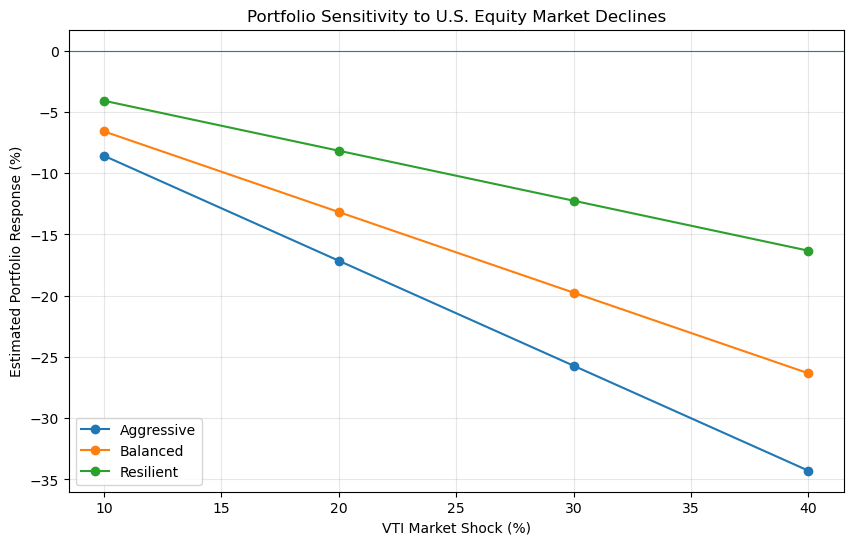

In [20]:
# Plot equity market sensitivity

plt.figure(figsize=(10, 6))

# Convert shock levels to numeric percentages for the x-axis
market_declines = [10, 20, 30, 40]

for portfolio in equity_sensitivity.index:
    plt.plot(
        market_declines,
        equity_sensitivity.loc[portfolio] * 100,
        marker="o",
        label=portfolio
    )

plt.title("Portfolio Sensitivity to U.S. Equity Market Declines")
plt.xlabel("VTI Market Shock (%)")
plt.ylabel("Estimated Portfolio Response (%)")

plt.axhline(0, linewidth=0.8)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation 
The equity-market sensitivity analysis shows clear differences in exposure to broad U.S. equity-market movements across the three portfolios. The Aggressive portfolio exhibits the highest market sensitivity and therefore experiences the largest estimated losses as the assumed VTI decline becomes more severe. The Balanced portfolio demonstrates moderate sensitivity, while the Resilient portfolio consistently experiences the smallest estimated response because of its lower exposure to equity-market risk and greater allocation to defensive assets. 

The increasing separation between the portfolios as market declines become more severe illustrates how differences in strategic asset allocation affect downside exposure. Because the analysis relies on historical beta and assumes a linear relationship between portfolio returns and VTI, the results should be interpreted as measures of market sensitivity rather than forecasts of actual portfolio losses during future downturns.

### Interest-Rate Sensitivity
### Purpose
The interest-rate sensitivity analysis estimates how changes in market yields may affect the BND allocation in each portfolio.

Because the portfolios hold different strategic weights in BND, they have different exposures to changes in bond prices. A first-order duration approximation is used to estimate the effect of hypothetical parallel yield shifts on BND and translate those changes into portfolio-level impacts.

The analysis isolates the modeled BND exposure rather than estimating the complete interest-rate sensitivity of every asset in the portfolio.

#### Methodology

Interest-rate sensitivity is estimated using the duration approximation:

$$
\frac{\Delta P}{P} \approx -D\Delta y
$$

where:

- **D** = BND's reported average duration
- **Δy** = assumed parallel change in market yields
- **ΔP/P** = estimated percentage change in BND's value

BND's reported average duration is used as the measure of the fund's current interest-rate sensitivity. The estimated change in BND is multiplied by each portfolio's strategic allocation to BND to estimate the corresponding portfolio-level impact.

The analysis assumes parallel shifts in interest rates and holds other portfolio exposures constant in order to isolate interest-rate risk. The duration approximation represents a first-order estimate and does not capture convexity, changes in credit spreads, or non-parallel movements in the yield curve.

The approximation does not include a convexity adjustment and becomes less precise as the assumed yield change becomes larger.

In [21]:
# Interest-rate sensitivity inputs

rate_sensitivity_inputs = pd.DataFrame({
    "Input": [
        "BND Average Duration",
        "Rate Shock Range"
    ],
    "Value": [
        "5.9 years",
        "-300 to +300 bps"
    ],
    "Source": [
        "Vanguard BND Fund Fact Sheet as of 09/2026",
        "Hypothetical sensitivity range"
    ]
})

rate_sensitivity_inputs.style.hide(axis="index")

Input,Value,Source
BND Average Duration,5.9 years,Vanguard BND Fund Fact Sheet as of 09/2026
Rate Shock Range,-300 to +300 bps,Hypothetical sensitivity range


### Interest-Rate Shock Analysis

In [22]:
# BND average duration
bnd_duration = 5.9

# Hypothetical parallel interest-rate shocks
rate_shocks = pd.Series({
    "-300 bps": -0.03,
    "-200 bps": -0.02,
    "-100 bps": -0.01,
    "+100 bps":  0.01,
    "+200 bps":  0.02,
    "+300 bps":  0.03
})

rate_shocks

-300 bps   -0.03
-200 bps   -0.02
-100 bps   -0.01
+100 bps    0.01
+200 bps    0.02
+300 bps    0.03
dtype: float64

In [23]:
# Estimate BND price response using duration

bnd_rate_sensitivity = (
    -bnd_duration * rate_shocks
)

# Create results table
bnd_rate_results = pd.DataFrame({
    "Rate Shock": rate_shocks.index,
    "Estimated BND Return": bnd_rate_sensitivity.values
})

# Display results
bnd_rate_results.style.hide(axis="index").format({
    "Estimated BND Return": "{:.2%}"
})

Rate Shock,Estimated BND Return
-300 bps,17.70%
-200 bps,11.80%
-100 bps,5.90%
+100 bps,-5.90%
+200 bps,-11.80%
+300 bps,-17.70%


In [24]:
# Extract BND allocation for each portfolio
bnd_weights = portfolio_weights.loc["BND"]

bnd_weights

Portfolio
Aggressive    0.05
Balanced      0.25
Resilient     0.45
Name: BND, dtype: float64

In [25]:
# Calculate portfolio-level impact of each rate shock

interest_rate_sensitivity = pd.DataFrame({
    shock_name: bnd_weights * bnd_return
    for shock_name, bnd_return in bnd_rate_sensitivity.items()
})

# Make Portfolio a regular column for cleaner display
interest_rate_sensitivity.index.name = "Portfolio"

interest_rate_sensitivity_display = (
    interest_rate_sensitivity
    .reset_index()
)

# Display results
interest_rate_sensitivity_display.style.hide(axis="index").format({
    "-300 bps": "{:.2%}",
    "-200 bps": "{:.2%}",
    "-100 bps": "{:.2%}",
    "+100 bps": "{:.2%}",
    "+200 bps": "{:.2%}",
    "+300 bps": "{:.2%}"
})

Portfolio,-300 bps,-200 bps,-100 bps,+100 bps,+200 bps,+300 bps
Aggressive,0.89%,0.59%,0.30%,-0.30%,-0.59%,-0.89%
Balanced,4.42%,2.95%,1.48%,-1.48%,-2.95%,-4.42%
Resilient,7.96%,5.31%,2.66%,-2.66%,-5.31%,-7.96%


#### DV01 Analysis
DV01 is reported as the approximate dollar magnitude of the BND exposure's value change for a one-basis-point yield movement. Under the duration approximation, a yield increase produces a loss, while a yield decrease produces a gain.

For the BND exposure:

$$
DV01 \approx \text{Market Value} \times D \times 0.0001
$$

where:

- **Market Value** = dollar amount invested in BND
- **D** = BND average duration
- **0.0001** = one basis point

A larger DV01 indicates greater dollar sensitivity to small changes in interest rates.

In [26]:
# Assume a standardized $100,000 portfolio value
portfolio_value = 100000

# Calculate dollar amount invested in BND for each portfolio
bnd_market_value = (
    portfolio_value * bnd_weights
)

# Calculate DV01 for each portfolio
portfolio_dv01 = (
    bnd_market_value
    * bnd_duration
    * 0.0001
)

# Create results table
dv01_results = pd.DataFrame({
    "Portfolio Value": portfolio_value,
    "BND Allocation": bnd_weights,
    "BND Market Value": bnd_market_value,
    "DV01": portfolio_dv01
})

# Make Portfolio a regular column
dv01_results.index.name = "Portfolio"
dv01_results = dv01_results.reset_index()

# Display results
dv01_results.style.hide(axis="index").format({
    "Portfolio Value": "${:,.0f}",
    "BND Allocation": "{:.0%}",
    "BND Market Value": "${:,.0f}",
    "DV01": "${:,.2f}"
})

Portfolio,Portfolio Value,BND Allocation,BND Market Value,DV01
Aggressive,"$100,000",5%,"$5,000",$2.95
Balanced,"$100,000",25%,"$25,000",$14.75
Resilient,"$100,000",45%,"$45,000",$26.55


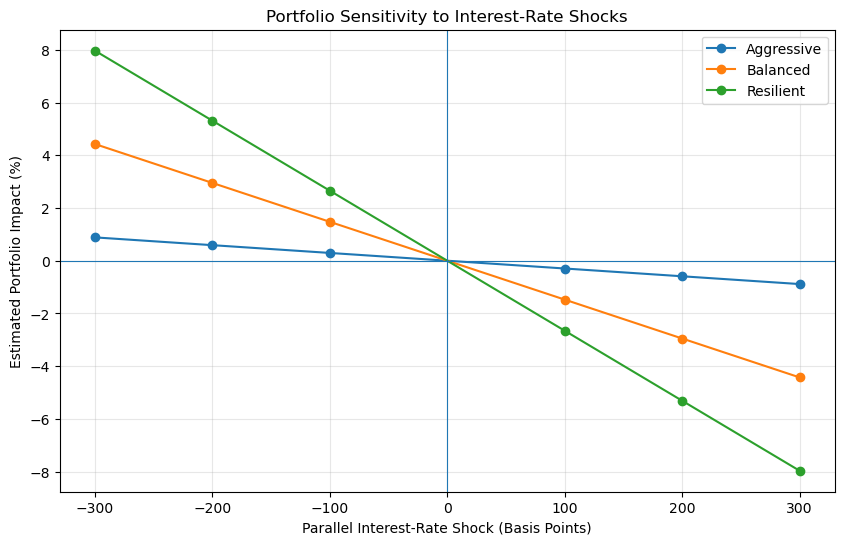

In [27]:
#Interest-Rate Sensitivity Visualization
# Plot portfolio interest-rate sensitivity
plt.figure(figsize=(10, 6))

# Rate shocks in basis points
rate_shock_bps = [-300, -200, -100, 100, 200, 300]

for portfolio in interest_rate_sensitivity.index:
    plt.plot(
        rate_shock_bps,
        interest_rate_sensitivity.loc[portfolio] * 100,
        marker="o",
        label=portfolio
    )

plt.title("Portfolio Sensitivity to Interest-Rate Shocks")
plt.xlabel("Parallel Interest-Rate Shock (Basis Points)")
plt.ylabel("Estimated Portfolio Impact (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation
The interest-rate sensitivity analysis demonstrates that the portfolios exhibit materially different exposure to changes in market yields because of differences in their fixed-income allocations. The Resilient portfolio displays the greatest sensitivity to interest-rate movements, followed by the Balanced portfolio, while the Aggressive portfolio exhibits substantially lower rate sensitivity. Falling yields generate estimated gains in the BND exposure, whereas rising yields generate estimated losses, with the magnitude of the portfolio-level effect increasing with both the size of the rate shock and the allocation to fixed income. 

The DV01 results reinforce this relationship in dollar terms by showing that portfolios with larger BND allocations experience greater changes in value for each basis-point movement in yields. These findings illustrate that reducing equity-market exposure through greater fixed-income allocation does not eliminate portfolio risk but instead changes the portfolio's exposure to different sources of market risk. The estimates rely on a first-order duration approximation and therefore do not capture convexity, credit-spread changes, or non-parallel movements in the yield curve.

### Multi-Factor Sensitivity Analysis

#### Purpose
The factor sensitivity analysis evaluates how the three portfolios respond to multiple systematic sources of market risk simultaneously. While the preceding equity-market and interest-rate sensitivity analyses isolate individual risk exposures, a multi-factor framework provides a broader view of the underlying drivers of portfolio returns.

The analysis estimates each portfolio's historical sensitivity to selected market factors and compares how differences in strategic asset allocation influence exposure to those factors. This provides a more detailed assessment of portfolio risk than a single-market beta by distinguishing among different sources of systematic risk.

#### Factor Selection

Five market factors are selected to represent major sources of risk relevant to the portfolios:

- **U.S. Equity Market:** VTI daily returns.
- **Interest Rates:** Daily change in the 10-year U.S. Treasury yield (FRED: DGS10).
- **Credit Spreads:** Daily change in the Moody's Baa corporate bond yield relative to the 10-year Treasury yield (FRED: BAA10Y).
- **U.S. Dollar:** Daily return of the Federal Reserve Broad U.S. Dollar Index (FRED: DTWEXBGS).
- **Commodities:** GSG daily returns as a proxy for broad commodity-market risk.

These factors are used to distinguish the portfolios' historical sensitivity to equity markets, interest rates, corporate credit conditions, currency movements, and commodities.

#### Factor Data Acquisition

In [28]:
print("Portfolio return data:")
print("Start:", portfolio_returns.index.min())
print("End:", portfolio_returns.index.max())
print("Observations:", len(portfolio_returns))

Portfolio return data:
Start: 2007-05-31 00:00:00
End: 2026-09-18 00:00:00
Observations: 4857


In [29]:
import yfinance as yf

factor_tickers = ["VTI", "GSG"]

factor_prices = yf.download(
    factor_tickers,
    start=portfolio_returns.index.min(),
    end=portfolio_returns.index.max() + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False
)["Close"]

factor_prices.head()

Ticker,GSG,VTI
Date,,
2007-05-31,41.200001,53.978092
2007-06-01,41.570000,54.197369
2007-06-04,42.099998,54.285755
2007-06-05,42.009998,54.009926
2007-06-06,42.029999,53.458271


In [30]:
market_factors = (
    factor_prices
    .pct_change(fill_method=None)
    .dropna()
)

market_factors = market_factors.rename(columns={
    "VTI": "Equity",
    "GSG": "Commodity"
})

market_factors.head()

Ticker,Commodity,Equity
Date,,
2007-06-01,0.008981,0.004062
2007-06-04,0.012750,0.001631
2007-06-05,-0.002138,-0.005081
2007-06-06,0.000476,-0.010214
2007-06-07,0.000476,-0.019713


In [31]:
%pip install pandas-datareader

Note: you may need to restart the kernel to use updated packages.


In [32]:
from pandas_datareader import data as web

In [33]:
fred_series = {
    "DGS10": "Interest_Rate",
    "BAA10Y": "Credit_Spread",
    "DTWEXBGS": "USD"
}

fred_data = web.DataReader(
    list(fred_series.keys()),
    "fred",
    start=portfolio_returns.index.min(),
    end=portfolio_returns.index.max()
)

fred_data = fred_data.rename(columns=fred_series)

fred_data.head()

,Interest_Rate,Credit_Spread,USD
DATE,,,
2007-05-31,4.90,1.60,94.3215
2007-06-01,4.95,1.60,94.1320
2007-06-04,4.93,1.58,93.9969
2007-06-05,4.98,1.57,93.9986
2007-06-06,4.97,1.60,94.1217


In [34]:
fred_summary = pd.DataFrame({
    "Start": fred_data.apply(lambda x: x.first_valid_index()),
    "End": fred_data.apply(lambda x: x.last_valid_index()),
    "Observations": fred_data.count(),
    "Missing": fred_data.isna().sum()
})

fred_summary

,Start,End,Observations,Missing
Interest_Rate,2007-05-31,2026-09-17,4828,208
Credit_Spread,2007-05-31,2026-09-17,4823,213
USD,2007-05-31,2026-09-11,4821,215


In [35]:
fred_data.tail()

,Interest_Rate,Credit_Spread,USD
DATE,,,
2026-09-11,4.96,1.50,118.2126
2026-09-14,4.97,1.47,NaN
2026-09-15,5.00,1.48,NaN
2026-09-16,5.01,1.43,NaN
2026-09-17,4.94,1.44,NaN


In [36]:
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5036 entries, 2007-05-31 to 2026-09-17
Freq: B
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Interest_Rate  4828 non-null   float64
 1   Credit_Spread  4823 non-null   float64
 2   USD            4821 non-null   float64
dtypes: float64(3)
memory usage: 157.4 KB


#### Factor Transformation

The raw factor series are transformed into measures appropriate for the multi-factor sensitivity analysis. Equity and commodity factors are measured using daily returns. Interest-rate and credit-spread factors are measured using daily changes in basis points, while the U.S. dollar factor is measured using the daily percentage change in the Federal Reserve Broad U.S. Dollar Index.

In [37]:
# Transform FRED factor series

fred_factors = pd.DataFrame(index=fred_data.index)

# Daily change in 10-Year Treasury yield, measured in basis points
fred_factors["Interest_Rate"] = (
    fred_data["Interest_Rate"].diff() * 100
)

# Daily change in Baa credit spread, measured in basis points
fred_factors["Credit_Spread"] = (
    fred_data["Credit_Spread"].diff() * 100
)

# Daily percentage change in Broad U.S. Dollar Index
fred_factors["USD"] = (
    fred_data["USD"].pct_change(fill_method=None)
)

fred_factors.head()

,Interest_Rate,Credit_Spread,USD
DATE,,,
2007-05-31,NaN,NaN,NaN
2007-06-01,5.0,0.0,-0.002009
2007-06-04,-2.0,-2.0,-0.001435
2007-06-05,5.0,-1.0,0.000018
2007-06-06,-1.0,3.0,0.001310


In [38]:
# Combine market and FRED factors

factor_data = pd.concat(
    [
        market_factors,
        fred_factors
    ],
    axis=1
)

# Arrange factors in a logical order
factor_data = factor_data[
    [
        "Equity",
        "Interest_Rate",
        "Credit_Spread",
        "USD",
        "Commodity"
    ]
]

factor_data.head()

,Equity,Interest_Rate,Credit_Spread,USD,Commodity
2007-05-31,NaN,NaN,NaN,NaN,NaN
2007-06-01,0.004062,5.0,0.0,-0.002009,0.008981
2007-06-04,0.001631,-2.0,-2.0,-0.001435,0.012750
2007-06-05,-0.005081,5.0,-1.0,0.000018,-0.002138
2007-06-06,-0.010214,-1.0,3.0,0.001310,0.000476


In [39]:
# Check transformed factor data

factor_summary = pd.DataFrame({
    "Start": factor_data.apply(lambda x: x.first_valid_index()),
    "End": factor_data.apply(lambda x: x.last_valid_index()),
    "Observations": factor_data.count(),
    "Missing": factor_data.isna().sum()
})

factor_summary

,Start,End,Observations,Missing
Equity,2007-06-01,2026-09-18,4856,181
Interest_Rate,2007-06-01,2026-09-17,4619,418
Credit_Spread,2007-06-01,2026-09-17,4609,428
USD,2007-06-01,2026-09-11,4621,416
Commodity,2007-06-01,2026-09-18,4856,181


In [40]:
factor_data.head(10)

,Equity,Interest_Rate,Credit_Spread,USD,Commodity
2007-05-31,NaN,NaN,NaN,NaN,NaN
2007-06-01,0.004062,5.0,0.0,-0.002009,0.008981
2007-06-04,0.001631,-2.0,-2.0,-0.001435,0.012750
2007-06-05,-0.005081,5.0,-1.0,0.000018,-0.002138
2007-06-06,-0.010214,-1.0,3.0,0.001310,0.000476
2007-06-07,-0.019713,14.0,0.0,0.002465,0.000476
2007-06-08,0.013699,1.0,2.0,0.004305,-0.023781
2007-06-11,0.001198,2.0,-1.0,-0.001080,0.014129
2007-06-12,-0.012301,12.0,-1.0,0.000438,-0.002162
2007-06-13,0.015618,-6.0,-2.0,0.002133,0.006259


The final regression sample contains only dates with complete portfolio and factor observations. It is therefore smaller than the full portfolio-return sample used in the earlier analyses.

This complete-case sample is used consistently across all three portfolio regressions so differences in the estimated sensitivities are not caused by different observation dates.

#### Factor and Portfolio Data Alignment

The transformed market factors are aligned with the daily portfolio returns using common observation dates. Because the underlying data series follow slightly different reporting and trading calendars, observations with incomplete factor or portfolio data are excluded from the regression sample. The original datasets are retained separately, while a complete modeling dataset is created for the multi-factor analysis.

In [41]:
# Combine portfolio returns and market factors

model_data = pd.concat(
    [portfolio_returns, factor_data],
    axis=1,
    join="inner"
)
model_data.head()

,Aggressive,Balanced,Resilient,Equity,Interest_Rate,Credit_Spread,USD,Commodity
2007-05-31,0.002857,0.002203,0.001999,NaN,NaN,NaN,NaN,NaN
2007-06-01,0.007015,0.005458,0.003460,0.004062,5.0,0.0,-0.002009,0.008981
2007-06-04,0.001120,0.000994,0.001095,0.001631,-2.0,-2.0,-0.001435,0.012750
2007-06-05,-0.004741,-0.004004,-0.003120,-0.005081,5.0,-1.0,0.000018,-0.002138
2007-06-06,-0.009978,-0.007555,-0.004277,-0.010214,-1.0,3.0,0.001310,0.000476


In [42]:
print("Model data before removing missing observations:")
print(f"Rows: {model_data.shape[0]}")
print(f"Columns: {model_data.shape[1]}")
model_data.isna().sum()

Model data before removing missing observations:
Rows: 4857
Columns: 8


Aggressive         0
Balanced           0
Resilient          0
Equity             1
Interest_Rate    246
Credit_Spread    253
USD              268
Commodity          1
dtype: int64

In [43]:
# Create complete regression sample

model_data_clean = model_data.dropna().copy()

print("Final regression sample:")
print(f"Observations: {len(model_data_clean)}")
print(f"Start date: {model_data_clean.index.min().date()}")
print(f"End date: {model_data_clean.index.max().date()}")
print(f"Missing values: {model_data_clean.isna().sum().sum()}")

Final regression sample:
Observations: 4553
Start date: 2007-06-01
End date: 2026-09-11
Missing values: 0


#### Factor Correlation Analysis

Before estimating the multi-factor regressions, correlations among the selected market factors are examined to assess whether the factors provide sufficiently distinct information. Strong correlations between explanatory variables may create multicollinearity, making it more difficult to distinguish their individual effects on portfolio returns.

The correlation analysis is used as a preliminary diagnostic to identify potentially overlapping risk exposures and evaluate the suitability of the selected factors for the regression model.

In [44]:
# Select the five explanatory factors

factor_columns = [
    "Equity",
    "Interest_Rate",
    "Credit_Spread",
    "USD",
    "Commodity"
]

# Calculate the factor correlation matrix

factor_correlation = model_data_clean[factor_columns].corr()

factor_correlation.round(3)

,Equity,Interest_Rate,Credit_Spread,USD,Commodity
Equity,1.000,0.277,-0.225,-0.313,0.378
Interest_Rate,0.277,1.000,-0.361,-0.004,0.230
Credit_Spread,-0.225,-0.361,1.000,0.074,-0.119
USD,-0.313,-0.004,0.074,1.000,-0.322
Commodity,0.378,0.230,-0.119,-0.322,1.000


### Interpretation

The correlation matrix indicates that the selected market factors exhibit economically plausible relationships without evidence of unusually strong pairwise correlations. Equity and commodity returns tend to move together, while equity returns and credit-spread changes generally move in opposite directions. Treasury-yield changes and credit-spread changes also exhibit a negative relationship, consistent with periods in which investors shift between riskier corporate debt and safer government securities.

The relatively moderate correlations suggest that the factors capture distinct, although related, sources of systematic risk. However, pairwise correlations alone cannot rule out multicollinearity arising from combinations of explanatory variables. Variance Inflation Factors are therefore calculated as an additional diagnostic before estimating the portfolio regressions.

#### Variance Inflation Factor Analysis

Variance Inflation Factors (VIFs) are calculated to assess multicollinearity among the explanatory variables. VIF measures the extent to which the variance of an estimated regression coefficient is inflated because a factor can be explained by the other factors in the model.

For each factor, an auxiliary regression is estimated using that factor as the dependent variable and the remaining factors as explanatory variables. The VIF is calculated as:

$$
VIF_j = \frac{1}{1-R_j^2}
$$

where $R_j^2$ is the coefficient of determination from the auxiliary regression for factor $j$.

A VIF of 1 indicates no linear relationship with the other explanatory variables. Larger values indicate greater multicollinearity. Values above 5 are commonly used as a preliminary warning threshold, although the interpretation depends on the model and research context.

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Select explanatory variables
X = model_data_clean[factor_columns]

# Add intercept for auxiliary regressions
X_vif = sm.add_constant(X)

# Calculate VIF for each explanatory factor
vif_data = pd.DataFrame({
    "Factor": factor_columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(1, X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data.style.hide(axis="index")

Factor,VIF
Equity,1.315000
Interest_Rate,1.251000
Credit_Spread,1.174000
USD,1.192000
Commodity,1.269000


### Interpretation

The VIF results indicate low multicollinearity among the selected market factors. All factors exhibit values close to one and remain well below commonly used warning thresholds, suggesting that no explanatory variable is highly predictable from the remaining factors.

Together with the correlation analysis, these results support retaining all five factors in the multi-factor regression model. The results do not indicate substantial multicollinearity among the selected factors, although coefficient stability must still be considered when interpreting the regression estimates. However, the explanatory power and statistical significance of the factors must still be evaluated through the regression results.

#### Multi-Factor Regression Analysis

The multi-factor regression analysis estimates the historical sensitivity of each portfolio to five systematic market risk factors. Ordinary Least Squares (OLS) regression is used to evaluate the relationship between daily portfolio returns and contemporaneous movements in equity markets, Treasury yields, credit spreads, the U.S. dollar, and commodities.

The model is specified as:

$$
R_{p,t} = \alpha_p
+ \beta_{EQ,p}F_{EQ,t}
+ \beta_{RATE,p}F_{RATE,t}
+ \beta_{CREDIT,p}F_{CREDIT,t}
+ \beta_{USD,p}F_{USD,t}
+ \beta_{COM,p}F_{COM,t}
+ \epsilon_{p,t}
$$

where $R_{p,t}$ is the daily return of portfolio $p$, $\alpha_p$ is the intercept, and the beta coefficients measure the portfolio's sensitivity to each market factor. The factors are measured as daily returns for Equity, USD, and Commodities, and daily basis-point changes for Interest Rates and Credit Spreads.

Separate regressions are estimated for the Aggressive Growth, Balanced Growth, and Resilient Growth portfolios. Heteroskedasticity and Autocorrelation Consistent (HAC) standard errors are used to account for potential heteroskedasticity and serial correlation in the daily regression residuals. The resulting coefficients are evaluated in terms of their direction, economic magnitude, statistical significance, and explanatory power.

In [46]:
# Estimate multi-factor regressions

import statsmodels.api as sm

# Explanatory variables
X = model_data_clean[factor_columns]

# Add intercept
X = sm.add_constant(X)

# Portfolio return columns
portfolio_columns = [
    "Aggressive",
    "Balanced",
    "Resilient"
]

# Store fitted models
factor_models = {}

for portfolio in portfolio_columns:

    y = model_data_clean[portfolio]

    model = sm.OLS(y, X).fit()

    factor_models[portfolio] = model

print("Multi-factor regressions estimated successfully.")

Multi-factor regressions estimated successfully.


In [47]:
# Display Aggressive Growth regression results

print(factor_models["Aggressive"].summary())

                            OLS Regression Results                            
Dep. Variable:             Aggressive   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 2.780e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:07:14   Log-Likelihood:                 21981.
No. Observations:                4553   AIC:                        -4.395e+04
Df Residuals:                    4547   BIC:                        -4.391e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -2.971e-07   2.88e-05     -0.010

In [48]:
# Estimate multi-factor regressions with HAC robust standard errors

import statsmodels.api as sm

# Explanatory variables
X = model_data_clean[factor_columns]

# Add intercept
X = sm.add_constant(X)

# Portfolio return columns
portfolio_columns = [
    "Aggressive",
    "Balanced",
    "Resilient"
]

# Store fitted models
factor_models = {}

for portfolio in portfolio_columns:

    y = model_data_clean[portfolio]

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    factor_models[portfolio] = model

print("Multi-factor regressions estimated with HAC robust standard errors.")


Multi-factor regressions estimated with HAC robust standard errors.


In [49]:
print(factor_models["Aggressive"].summary())

                            OLS Regression Results                            
Dep. Variable:             Aggressive   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     4568.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:07:14   Log-Likelihood:                 21981.
No. Observations:                4553   AIC:                        -4.395e+04
Df Residuals:                    4547   BIC:                        -4.391e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -2.971e-07   2.55e-05     -0.012

#### Interpretation

The HAC specification produces the same coefficient estimates and explanatory power as the conventional OLS model, while adjusting the standard errors for potential heteroskedasticity and serial correlation. The results indicate that the Aggressive Growth portfolio is strongly associated with equity-market movements, with additional sensitivity to interest-rate, U.S. dollar, and commodity factors.

The credit-spread coefficient is not statistically significant at the conventional 5% level under HAC inference, despite appearing significant under conventional OLS standard errors. This suggests that the evidence for a distinct credit-spread sensitivity is less robust than the initial regression indicated. The result should therefore not be interpreted as evidence that credit-spread widening benefits the portfolio.

The high explanatory power is consistent with the portfolio's substantial exposure to market-traded assets and the contemporaneous nature of the factor model. It should not be interpreted as evidence of out-of-sample predictive accuracy.

#### Multi-Factor Regression Comparison

The estimated factor sensitivities are compared across the three portfolios to evaluate how differences in strategic asset allocation influence exposure to systematic market risks. HAC standard errors are used for statistical inference, while adjusted R-squared is reported to assess the explanatory power of each model.

Because the factors are measured in different units, coefficient magnitudes should not be compared directly across different factors. Equity, USD, and commodity coefficients represent sensitivity to percentage returns, while interest-rate and credit-spread coefficients represent sensitivity to basis-point changes.

In [50]:
# Create multi-factor regression comparison table

comparison_rows = []

for portfolio in portfolio_columns:

    model = factor_models[portfolio]

    for factor in factor_columns:

        comparison_rows.append({
            "Portfolio": portfolio,
            "Factor": factor,
            "Coefficient": model.params[factor],
            "HAC SE": model.bse[factor],
            "p-value": model.pvalues[factor],
            "Significant (5%)": model.pvalues[factor] < 0.05,
            "Adjusted R²": model.rsquared_adj
        })
factor_comparison = pd.DataFrame(comparison_rows)
factor_comparison

# Create compact multi-factor comparison table

comparison_table = pd.DataFrame(index=factor_columns)

for portfolio in portfolio_columns:
    model = factor_models[portfolio]

    values = []

    for factor in factor_columns:
        coefficient = model.params[factor]
        p_value = model.pvalues[factor]

        # Express rate and credit sensitivity as portfolio % per +100 bp
        if factor in ["Interest_Rate", "Credit_Spread"]:
            coefficient *= 10000

        # Add significance stars
        if p_value < 0.01:
            stars = "***"
        elif p_value < 0.05:
            stars = "**"
        elif p_value < 0.10:
            stars = "*"
        else:
            stars = ""

        values.append(f"{coefficient:.3f}{stars}")

    comparison_table[portfolio] = values

# Add adjusted R-squared
comparison_table.loc["Adjusted R²"] = [
    f"{factor_models[p].rsquared_adj:.3f}"
    for p in portfolio_columns
]

# Clean row labels
comparison_table.index = [
    "Equity",
    "Interest Rate (+100 bp)",
    "Credit Spread (+100 bp)",
    "USD",
    "Commodity",
    "Adjusted R²"
]

comparison_table.style.set_caption(
    "Multi-Factor Regression Results (HAC Standard Errors)"
)

,Aggressive,Balanced,Resilient
Equity,0.818***,0.634***,0.401***
Interest Rate (+100 bp),-0.188**,-1.223***,-2.559***
Credit Spread (+100 bp),0.258*,0.043,-0.108
USD,-0.316***,-0.286***,-0.262***
Commodity,0.028***,0.027***,0.030***
Adjusted R²,0.968,0.956,0.910


*Notes:* Equity, USD, and Commodity coefficients represent return sensitivities to a 1% factor movement. Interest Rate and Credit Spread coefficients represent the portfolio percentage-return response to a +100 basis-point change. Statistical significance is based on HAC standard errors with five lags. ***, **, and * indicate significance at the 1%, 5%, and 10% levels, respectively. Adjusted R² measures in-sample explanatory power.

The coefficients describe contemporaneous historical associations. Because VTI is directly held in the portfolios and is also included as a regression factor, part of the model's high explanatory power reflects the portfolios' constructed asset exposures. Adjusted R² should not be interpreted as out-of-sample forecasting accuracy.

#### Interpretation

The multi-factor regression results reveal distinct risk exposures across the three portfolio strategies. Equity-market sensitivity declines from Aggressive Growth to Resilient Growth, consistent with the reduction in equity allocations. In contrast, interest-rate sensitivity becomes increasingly negative as fixed-income allocations rise, indicating that the portfolios exchange some equity-market exposure for greater sensitivity to changes in Treasury yields.

The portfolios also exhibit negative sensitivity to U.S. dollar movements and positive sensitivity to commodity-market returns. Credit-spread coefficients are not statistically significant under HAC inference, so their estimated signs should not be interpreted as reliable evidence of a distinct credit-risk effect.

The models explain a substantial portion of the portfolios' historical daily-return variation, although explanatory power declines as the portfolios become more defensively allocated. This is consistent with the selected factors capturing a larger share of the Aggressive portfolio's market exposure than the Resilient portfolio's. The results describe contemporaneous historical relationships rather than out-of-sample predictive performance.

Overall, the analysis demonstrates that diversification changes the composition of portfolio risk rather than eliminating it. The reduction in equity sensitivity is accompanied by greater interest-rate exposure, highlighting the importance of evaluating multiple risk factors when comparing strategic asset allocations.

## Part III — Reverse Stress Testing

Reverse stress testing begins with an adverse portfolio outcome and works backward to identify the market movements that could produce it.

This section evaluates illustrative portfolio losses of 10%, 20%, and 30%. The thresholds are used as common analytical benchmarks across the three strategies rather than as formal institutional risk limits.

Two approaches are considered. The first estimates the equity-market decline required to reach each threshold while holding other factors constant. The second applies and scales historically observed combinations of market-factor movements. The analysis uses the estimated equity sensitivities from the multi-factor regression to compare how the three portfolios respond as equity-market conditions deteriorate. In an institutional setting, reverse stress testing thresholds would typically be calibrated to the organization's risk appetite, capital or liquidity constraints, and specific risk-management objectives.

This provides a direct comparison of the portfolios' vulnerability to severe equity-market movements and illustrates how differences in strategic asset allocation affect their capacity to absorb market losses.

The results are linear approximations based on the sensitivities estimated in Part II. They are not forecasts, probabilities, or unique solutions to the reverse stress problem.

### Scenario 1 - Equity Onlys Loss Threshold Analysis


In [51]:
# Illustrative portfolio-loss thresholds
loss_thresholds = [0.10, 0.20, 0.30]

# Portfolio columns
portfolio_columns = [
    "Aggressive",
    "Balanced",
    "Resilient"
]

#### Stress Horizon and Model Assumptions

The analysis considers cumulative portfolio losses over a hypothetical market stress episode rather than ordinary one-day movements. The selected loss thresholds are used to identify the severity of market conditions required to produce substantial portfolio losses.

The initial analysis applies the historical equity sensitivities estimated in Part II as linear approximations. Other risk factors are held constant to isolate equity-market exposure. Because the regression coefficients were estimated using daily observations, their application to larger cumulative shocks is an approximation and does not account for changes in factor relationships, nonlinear effects, or portfolio rebalancing during the stress episode.

The resulting shocks are therefore interpreted as analytical break-even conditions rather than forecasts or estimates of the probability of reaching a loss threshold.

In [52]:
# Calculate the equity decline required to reach each loss threshold
reverse_stress_rows = []

for portfolio in portfolio_columns:
    equity_beta = factor_models[portfolio].params["Equity"]

    for threshold in loss_thresholds:
        required_equity_shock = -threshold / equity_beta

        reverse_stress_rows.append({
            "Portfolio": portfolio,
            "Loss Threshold": threshold,
            "Required Equity Shock": required_equity_shock
        })

reverse_stress_results = pd.DataFrame(reverse_stress_rows)

display(
    reverse_stress_results.style
    .format({
        "Loss Threshold": "{:.0%}",
        "Required Equity Shock": "{:.2%}"
    })
    .hide(axis="index")
)

Portfolio,Loss Threshold,Required Equity Shock
Aggressive,10%,-12.22%
Aggressive,20%,-24.45%
Aggressive,30%,-36.67%
Balanced,10%,-15.78%
Balanced,20%,-31.57%
Balanced,30%,-47.35%
Resilient,10%,-24.96%
Resilient,20%,-49.92%
Resilient,30%,-74.88%


#### Interpretation

The loss threshold analysis shows that the equity-market decline required to produce a given portfolio loss increases as the portfolios become more defensively allocated. The Aggressive Growth portfolio reaches each loss threshold under a smaller equity decline, while the Resilient Growth portfolio requires substantially more severe equity-market movements. This pattern is consistent with the reduction in equity exposure across the three strategies and demonstrates the relative protection provided by defensive allocations under an equity-only stress.

The required shocks become particularly severe at higher loss thresholds, especially for the Resilient Growth portfolio. These results should be interpreted as linear sensitivity approximations rather than precise forecasts of crisis outcomes. The calculations assume that historical equity sensitivities remain constant and that other risk factors do not change. In an actual market crisis, interest rates, credit spreads, currencies, and commodity prices may move simultaneously, potentially increasing or offsetting portfolio losses.


### Scenario 2: Multi-Factor Reverse Stress Testing

#### Purpose

The multi-factor reverse stress analysis identifies combinations of market shocks that could produce the selected portfolio-loss thresholds. Building on the single-factor baseline, the analysis incorporates simultaneous movements in equity markets, Treasury yields, credit spreads, the U.S. dollar, and commodity markets.

Historically informed joint shock directions are used to construct coherent stress scenarios, which are then scaled to determine the severity required to reach each loss threshold. The analysis compares how the three portfolio strategies respond to the same underlying market conditions and identifies the combinations of risk factors that may contribute to substantial portfolio losses.

The resulting scenarios are illustrative and do not represent forecasts, probabilities, or unique solutions. The analysis assumes that the estimated factor sensitivities remain constant as shocks are scaled and therefore does not capture nonlinear effects, changing correlations, or portfolio rebalancing during a crisis.

#### Historical Stress Episode Selection

The acute phase of the 2008 global financial crisis is selected as the initial historical stress episode. The analysis examines the period from September 12 through October 10, 2008, beginning with the final trading day before the bankruptcy of Lehman Brothers and extending through the subsequent escalation of financial-market stress.

This period provides an economically grounded basis for examining simultaneous movements in equity markets, Treasury yields, credit spreads, the U.S. dollar, and commodities. The objective is not to identify the historically worst possible outcome, but to use an observable episode to construct a coherent joint stress direction.

The selected window represents a focused phase of the crisis rather than the entire 2007–2009 financial crisis. Its factor movements will be measured from historical data and subsequently used to evaluate the severity of shocks required to reach the selected portfolio-loss thresholds.

#### Historical Stress Direction 1: 2008 Financial Crisis

In [53]:
# Historical stress episode: acute phase of the 2008 financial crisis
stress_start = pd.Timestamp("2008-09-12")
stress_end = pd.Timestamp("2008-10-10")

stress_episode_name = "2008 Financial Crisis — Acute Phase"

#### Historical Factor Movement Calculation

The historical joint shock is constructed from the observed changes in the five risk factors over the selected stress episode. Equity, U.S. dollar, and commodity movements are calculated as cumulative percentage changes between the beginning and end of the episode. Treasury yields and credit spreads are measured as changes in basis points.

For return-based factors:

$$
\Delta F = \frac{F_{end}}{F_{start}} - 1
$$

For interest rates and credit spreads:

$$
\Delta F_{bp} = (F_{end} - F_{start}) \times 100
$$

The calculations use the original price and index levels rather than the complete-case regression dataset. The first and last dates with observations available for all five factors are used to maintain a consistent measurement window.

In [54]:
# Combine original factor levels
stress_factor_levels = pd.concat(
    [
        factor_prices[["VTI", "GSG"]].rename(columns={
            "VTI": "Equity",
            "GSG": "Commodity"
        }),
        fred_data[["Interest_Rate", "Credit_Spread", "USD"]]
    ],
    axis=1
)

# Restrict to the selected historical episode
stress_window = stress_factor_levels.loc[
    stress_start:stress_end
].dropna()

# Verify that the window contains sufficient observations
if len(stress_window) < 2:
    raise ValueError(
        "The selected stress window does not contain "
        "enough complete factor observations."
    )

# Identify the actual common observation dates
actual_start = stress_window.index[0]
actual_end = stress_window.index[-1]

print(f"Stress episode: {stress_episode_name}")
print(f"Actual measurement window: {actual_start.date()} to {actual_end.date()}")
print(f"Common observations: {len(stress_window)}")

Stress episode: 2008 Financial Crisis — Acute Phase
Actual measurement window: 2008-09-12 to 2008-10-10
Common observations: 21


In [55]:
# Beginning and ending factor levels
start_levels = stress_window.iloc[0]
end_levels = stress_window.iloc[-1]

# Calculate observed historical factor movements
observed_shocks = pd.Series({
    "Equity": (
        end_levels["Equity"] / start_levels["Equity"] - 1
    ),
    "Interest_Rate": (
        end_levels["Interest_Rate"] - start_levels["Interest_Rate"]
    ) * 100,
    "Credit_Spread": (
        end_levels["Credit_Spread"] - start_levels["Credit_Spread"]
    ) * 100,
    "USD": (
        end_levels["USD"] / start_levels["USD"] - 1
    ),
    "Commodity": (
        end_levels["Commodity"] / start_levels["Commodity"] - 1
    )
})

# Create a readable summary table
historical_shock_table = pd.DataFrame({
    "Factor": factor_columns,
    "Start Level": [
        start_levels[factor] for factor in factor_columns
    ],
    "End Level": [
        end_levels[factor] for factor in factor_columns
    ],
    "Observed Movement": [
        (
            f"{observed_shocks[factor] * 100:+.2f}%"
            if factor in ["Equity", "USD", "Commodity"]
            else f"{observed_shocks[factor]:+.1f} bp"
        )
        for factor in factor_columns
    ]
})

display(
    historical_shock_table.style
    .format({
        "Start Level": "{:.2f}",
        "End Level": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption("Observed Historical Factor Movements")
)

Factor,Start Level,End Level,Observed Movement
Equity,45.88,32.25,-29.71%
Interest_Rate,3.74,3.89,+15.0 bp
Credit_Spread,3.43,4.86,+143.0 bp
USD,91.47,98.00,+7.14%
Commodity,53.95,42.95,-20.39%


#### Model-Based Portfolio Response

The observed historical factor movements are applied to the estimated multi-factor regression sensitivities to calculate an approximate portfolio response. The calculation combines the simultaneous equity, interest-rate, credit-spread, U.S. dollar, and commodity shocks using the coefficients estimated in Part II.

$$
\widehat{R}_{p,stress}
=
\beta_{EQ,p}\Delta Equity
+
\beta_{RATE,p}\Delta Rate
+
\beta_{CREDIT,p}\Delta Credit
+
\beta_{USD,p}\Delta USD
+
\beta_{COM,p}\Delta Commodity
$$

The intercept is excluded because the objective is to isolate the portfolio response to the specified market shocks rather than estimate an unconditional return. The resulting response is compared with the portfolio's realized cumulative return over the same historical episode as a reasonableness check.

Because the coefficients were estimated using daily observations, applying them to cumulative episode-level movements is a linear approximation. Differences between the model-based and realized returns may reflect compounding, omitted risk factors, changing sensitivities, and other effects not captured by the model.

In [56]:
# Calculate model-based portfolio responses to the historical joint shock
historical_model_responses = {}

for portfolio in portfolio_columns:
    model = factor_models[portfolio]

    # Match the shock vector to the regression factor order
    coefficients = model.params[factor_columns]
    shocks = observed_shocks.reindex(factor_columns)

    # Linear factor-sensitivity approximation
    historical_model_responses[portfolio] = (
        coefficients * shocks
    ).sum()

historical_model_responses = pd.Series(
    historical_model_responses,
    name="Model-Based Return"
)

In [57]:
# Select daily portfolio returns over the same close-to-close episode
historical_portfolio_returns = portfolio_returns.loc[
    (portfolio_returns.index > actual_start)
    & (portfolio_returns.index <= actual_end),
    portfolio_columns
]

# Calculate realized cumulative portfolio returns
historical_actual_returns = (
    (1 + historical_portfolio_returns).prod() - 1
)

historical_actual_returns.name = "Realized Historical Return"

# Compare model-based and realized returns
historical_response_comparison = pd.DataFrame({
    "Model-Based Return": historical_model_responses,
    "Realized Historical Return": historical_actual_returns
})

historical_response_comparison["Difference (pp)"] = (
    historical_response_comparison["Model-Based Return"]
    - historical_response_comparison["Realized Historical Return"]
) * 100

display(
    historical_response_comparison.style
    .format({
        "Model-Based Return": "{:+.2%}",
        "Realized Historical Return": "{:+.2%}",
        "Difference (pp)": "{:+.2f}"
    })
    .set_caption(
        "Historical Stress: Model-Based vs. Realized Portfolio Returns"
    )
)

,Model-Based Return,Realized Historical Return,Difference (pp)
Aggressive,-26.79%,-25.81%,-0.98
Balanced,-21.53%,-21.72%,+0.18
Resilient,-14.92%,-15.39%,+0.47


#### Interpretation

The model-based portfolio responses are reasonably close to the realized cumulative returns over the selected historical stress episode. The model reproduces the relative loss ranking across the three strategies, with Aggressive Growth experiencing the largest decline and Resilient Growth the smallest. This suggests that the selected factors capture a substantial portion of the portfolios' historical exposure to the joint market movements observed during the episode.

The comparison provides a useful reasonableness check for the linear factor-sensitivity framework, but it should not be interpreted as independent predictive validation. The regression was estimated using a historical sample that includes the selected episode, and the model applies daily sensitivities to cumulative market movements. Differences between estimated and realized returns may reflect compounding, omitted exposures, changing sensitivities, and other effects not captured by the linear approximation.

Overall, the results support using the observed joint shock as an illustrative starting point for reverse stress testing. The subsequent analysis will determine how the severity of this shock combination must change to reach the selected portfolio-loss thresholds, while recognizing that historical relationships may not remain stable under more extreme conditions.


#### Reverse Stress Scaling Methodology

The observed historical joint shock is scaled to determine the severity required to reach each selected portfolio-loss threshold. The scaling procedure preserves the relative direction and magnitude of the five historical factor movements while adjusting their overall severity.

Let $\mathbf{s}$ represent the observed historical factor-shock vector and $\boldsymbol{\beta}_p$ the estimated factor sensitivities for portfolio $p$. The model-based response to the historical episode is:

$$
\widehat{R}_{p,stress}
=
\boldsymbol{\beta}_p^\top \mathbf{s}
$$

For a target portfolio-loss threshold $L$, the required scaling factor is:

$$
\lambda_{p,L}
=
\frac{-L}{\widehat{R}_{p,stress}}
$$

The corresponding reverse stress scenario is:

$$
\mathbf{s}_{p,L}^{*}
=
\lambda_{p,L}\mathbf{s}
$$

A scaling factor below one represents a less severe version of the observed historical shock, while a factor above one represents an extrapolation beyond its observed magnitude. The procedure identifies one joint shock combination capable of reaching the specified loss threshold under the linear model; it does not identify a unique, most likely, or necessarily plausible scenario.

The resulting factor movements are evaluated for economic and mathematical feasibility. In particular, simple returns cannot fall below −100%, and increasingly large scaling factors may imply market conditions outside the range in which the historical sensitivities can reasonably be expected to remain stable.

In [58]:
import numpy as np

# Scale the observed historical joint shock to each loss threshold
reverse_stress_rows = []
reverse_stress_shocks = []

for portfolio in portfolio_columns:
    model = factor_models[portfolio]

    # Use the full-precision model response from the previous calculation
    baseline_response = historical_model_responses[portfolio]

    if not np.isfinite(baseline_response) or baseline_response >= 0:
        raise ValueError(
            f"{portfolio}: the historical scenario must produce "
            "a finite model-based loss before it can be scaled."
        )

    coefficients = model.params[factor_columns]

    for threshold in loss_thresholds:

        # Scaling factor required to reach the target loss
        scale = -threshold / baseline_response

        # Scale all five historical factor movements together
        scaled_shocks = observed_shocks.reindex(
            factor_columns
        ) * scale

        # Verify the implied portfolio loss
        implied_loss = -(
            coefficients * scaled_shocks
        ).sum()

        # Check mathematical bounds for simple-return factors
        return_factors = ["Equity", "USD", "Commodity"]

        return_bounds_valid = (
            scaled_shocks.loc[return_factors] >= -1
        ).all()

        reverse_stress_rows.append({
            "Portfolio": portfolio,
            "Loss Threshold": threshold,
            "Scaling Factor": scale,
            "Model-Implied Loss": implied_loss,
            "Return Bounds": (
                "Within bounds"
                if return_bounds_valid
                else "Outside bounds"
            )
        })

        reverse_stress_shocks.append({
            "Portfolio": portfolio,
            "Loss Threshold": threshold,
            **scaled_shocks.to_dict()
        })

reverse_stress_scaling = pd.DataFrame(reverse_stress_rows)

reverse_stress_factor_shocks = pd.DataFrame(
    reverse_stress_shocks
)

In [59]:
#display results
display(
    reverse_stress_scaling.style
    .format({
        "Loss Threshold": "{:.0%}",
        "Scaling Factor": "{:.2f}x",
        "Model-Implied Loss": "{:.2%}"
    })
    .hide(axis="index")
    .set_caption(
        "Reverse Stress Scaling — 2008 Historical Joint Shock"
    )
)

Portfolio,Loss Threshold,Scaling Factor,Model-Implied Loss,Return Bounds
Aggressive,10%,0.37x,10.00%,Within bounds
Aggressive,20%,0.75x,20.00%,Within bounds
Aggressive,30%,1.12x,30.00%,Within bounds
Balanced,10%,0.46x,10.00%,Within bounds
Balanced,20%,0.93x,20.00%,Within bounds
Balanced,30%,1.39x,30.00%,Within bounds
Resilient,10%,0.67x,10.00%,Within bounds
Resilient,20%,1.34x,20.00%,Within bounds
Resilient,30%,2.01x,30.00%,Within bounds


In [60]:
# Create a readable table of the scaled factor shocks
reverse_stress_shock_display = reverse_stress_factor_shocks.copy()

for factor in ["Equity", "USD", "Commodity"]:
    reverse_stress_shock_display[factor] = (
        reverse_stress_shock_display[factor]
        .map(lambda x: f"{x:+.2%}")
    )

for factor in ["Interest_Rate", "Credit_Spread"]:
    reverse_stress_shock_display[factor] = (
        reverse_stress_shock_display[factor]
        .map(lambda x: f"{x:+.1f} bp")
    )

reverse_stress_shock_display["Loss Threshold"] = (
    reverse_stress_shock_display["Loss Threshold"]
    .map(lambda x: f"{x:.0%}")
)

reverse_stress_shock_display = (
    reverse_stress_shock_display.rename(columns={
        "Interest_Rate": "Interest Rate",
        "Credit_Spread": "Credit Spread"
    })
)

display(
    reverse_stress_shock_display.style
    .hide(axis="index")
    .set_caption(
        "Market Shocks Required to Reach Portfolio-Loss Thresholds"
    )
)

Portfolio,Loss Threshold,Equity,Interest Rate,Credit Spread,USD,Commodity
Aggressive,10%,-11.09%,+5.6 bp,+53.4 bp,+2.66%,-7.61%
Aggressive,20%,-22.18%,+11.2 bp,+106.7 bp,+5.33%,-15.22%
Aggressive,30%,-33.27%,+16.8 bp,+160.1 bp,+7.99%,-22.83%
Balanced,10%,-13.80%,+7.0 bp,+66.4 bp,+3.31%,-9.47%
Balanced,20%,-27.60%,+13.9 bp,+132.8 bp,+6.63%,-18.94%
Balanced,30%,-41.39%,+20.9 bp,+199.2 bp,+9.94%,-28.40%
Resilient,10%,-19.91%,+10.1 bp,+95.8 bp,+4.78%,-13.67%
Resilient,20%,-39.83%,+20.1 bp,+191.7 bp,+9.57%,-27.33%
Resilient,30%,-59.74%,+30.2 bp,+287.5 bp,+14.35%,-41.00%


#### Interpretation

The reverse stress results show that progressively more severe versions of the historical joint shock are required to reach the selected loss thresholds as the portfolios become more defensively allocated. The Aggressive Growth portfolio reaches each threshold under the smallest scaling factor, while Resilient Growth requires the largest. This pattern is consistent with the differences in strategic asset allocation and the lower historical equity sensitivity of the more defensive portfolios.

The implied market shocks demonstrate how simultaneous movements across multiple risk factors can contribute to substantial portfolio losses. Compared with the equity-only baseline, the multi-factor analysis provides a broader representation of adverse market conditions by incorporating Treasury yields, credit spreads, the U.S. dollar, and commodities. However, the estimated contribution of credit-spread movements should be interpreted cautiously because the credit coefficients were not statistically significant under HAC inference.

The more severe reverse stress scenarios involve substantial extrapolation beyond the observed historical episode. Although the calculated return shocks remain within mathematical bounds, this does not establish their economic plausibility. The results rely on a linear sensitivity approximation and assume that historical factor relationships remain constant as the joint shock is scaled. They therefore identify illustrative combinations capable of reaching the loss thresholds under the model, rather than forecasts, probabilities, or unique worst-case scenarios.

Overall, the analysis demonstrates that defensive allocation can increase the severity of market conditions required to produce a given portfolio loss, but it does not eliminate exposure to adverse joint market movements. The findings provide a basis for comparing portfolio vulnerabilities and evaluating how different historical stress patterns may affect the three strategies.

#### Historical Stress Direction 2: 2022 Inflation and Interest-Rate Shock

The 2022 inflation and interest-rate shock is selected as a second historical stress direction to examine how the portfolios respond when rising interest rates accompany adverse equity-market conditions. This episode provides a contrast with the acute 2008 financial crisis and is particularly relevant to the portfolios' differing fixed-income allocations.

The analysis uses January 3 through December 30, 2022, representing the first and last U.S. trading days of the calendar year. The window is selected to capture the broader inflation and monetary-tightening environment rather than to identify the maximum historical portfolio loss.

The same five-factor framework and reverse stress methodology are applied to this episode. The observed joint factor movements will be measured, used to estimate portfolio responses, and scaled to the selected loss thresholds. Because the 2022 episode is substantially longer than the 2008 window, comparisons will focus on differences in risk-factor composition and portfolio vulnerability rather than treating the two episodes as equivalent in duration.

In [61]:
# Historical stress episode: 2022 inflation and interest-rate shock
stress_2022_start = pd.Timestamp("2022-01-03")
stress_2022_end = pd.Timestamp("2022-12-30")

stress_2022_name = "2022 Inflation and Interest-Rate Shock"

In [62]:
# Restrict original factor levels to the 2022 episode
stress_2022_window = stress_factor_levels.loc[
    stress_2022_start:stress_2022_end
].dropna()

# Verify sufficient observations
if len(stress_2022_window) < 2:
    raise ValueError(
        "The selected 2022 stress window does not contain "
        "enough complete factor observations."
    )

# Identify actual common observation dates
actual_2022_start = stress_2022_window.index[0]
actual_2022_end = stress_2022_window.index[-1]

print(f"Stress episode: {stress_2022_name}")
print(
    f"Actual measurement window: "
    f"{actual_2022_start.date()} to {actual_2022_end.date()}"
)
print(f"Common observations: {len(stress_2022_window)}")

Stress episode: 2022 Inflation and Interest-Rate Shock
Actual measurement window: 2022-01-03 to 2022-12-30
Common observations: 249


In [63]:
# Beginning and ending factor levels
start_2022_levels = stress_2022_window.iloc[0]
end_2022_levels = stress_2022_window.iloc[-1]

# Calculate observed historical factor movements
observed_2022_shocks = pd.Series({
    "Equity": (
        end_2022_levels["Equity"]
        / start_2022_levels["Equity"] - 1
    ),
    "Interest_Rate": (
        end_2022_levels["Interest_Rate"]
        - start_2022_levels["Interest_Rate"]
    ) * 100,
    "Credit_Spread": (
        end_2022_levels["Credit_Spread"]
        - start_2022_levels["Credit_Spread"]
    ) * 100,
    "USD": (
        end_2022_levels["USD"]
        / start_2022_levels["USD"] - 1
    ),
    "Commodity": (
        end_2022_levels["Commodity"]
        / start_2022_levels["Commodity"] - 1
    )
})

# Create a readable summary table
historical_2022_shock_table = pd.DataFrame({
    "Factor": factor_columns,
    "Start Level": [
        start_2022_levels[factor] for factor in factor_columns
    ],
    "End Level": [
        end_2022_levels[factor] for factor in factor_columns
    ],
    "Observed Movement": [
        (
            f"{observed_2022_shocks[factor] * 100:+.2f}%"
            if factor in ["Equity", "USD", "Commodity"]
            else f"{observed_2022_shocks[factor]:+.1f} bp"
        )
        for factor in factor_columns
    ]
})

display(
    historical_2022_shock_table.style
    .format({
        "Start Level": "{:.2f}",
        "End Level": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption(
        "Observed Historical Factor Movements — 2022"
    )
)

Factor,Start Level,End Level,Observed Movement
Equity,228.05,182.37,-20.03%
Interest_Rate,1.63,3.88,+225.0 bp
Credit_Spread,1.82,1.99,+17.0 bp
USD,115.41,121.43,+5.21%
Commodity,17.18,21.23,+23.57%


#### Model-Based Portfolio Response and Historical Comparison

The observed 2022 factor movements are applied to the multi-factor regression sensitivities estimated in Part II to calculate approximate portfolio responses. The resulting estimates are compared with the portfolios' realized cumulative returns over the same close-to-close period.

This comparison provides an in-sample reasonableness check of the linear factor-sensitivity framework under an inflation- and interest-rate-driven stress environment. The estimates are not intended to represent independent predictive validation, and differences may reflect compounding, omitted exposures, changing sensitivities, and other effects not captured by the model.

In [64]:
# Apply the observed 2022 joint shock to the regression models
historical_2022_model_responses = {}

for portfolio in portfolio_columns:
    model = factor_models[portfolio]

    coefficients = model.params[factor_columns]
    shocks = observed_2022_shocks.reindex(factor_columns)

    historical_2022_model_responses[portfolio] = (
        coefficients * shocks
    ).sum()

historical_2022_model_responses = pd.Series(
    historical_2022_model_responses,
    name="Model-Based Return"
)

# Calculate realized cumulative portfolio returns
# from the January 3 close through the December 30 close
historical_2022_portfolio_returns = portfolio_returns.loc[
    (portfolio_returns.index > actual_2022_start)
    & (portfolio_returns.index <= actual_2022_end),
    portfolio_columns
]

historical_2022_actual_returns = (
    (1 + historical_2022_portfolio_returns).prod() - 1
)

historical_2022_actual_returns.name = "Realized Historical Return"

# Compare model-based and realized returns
historical_2022_response_comparison = pd.DataFrame({
    "Model-Based Return": historical_2022_model_responses,
    "Realized Historical Return": historical_2022_actual_returns
})

historical_2022_response_comparison["Difference (pp)"] = (
    historical_2022_response_comparison["Model-Based Return"]
    - historical_2022_response_comparison["Realized Historical Return"]
) * 100

display(
    historical_2022_response_comparison.style
    .format({
        "Model-Based Return": "{:+.2%}",
        "Realized Historical Return": "{:+.2%}",
        "Difference (pp)": "{:+.2f}"
    })
    .set_caption(
        "2022 Stress: Model-Based vs. Realized Portfolio Returns"
    )
)

,Model-Based Return,Realized Historical Return,Difference (pp)
Aggressive,-17.75%,-16.37%,-1.39
Balanced,-16.30%,-14.89%,-1.41
Resilient,-14.47%,-12.64%,-1.83


#### Interpretation

The model-based responses are reasonably close to the realized portfolio returns during the selected 2022 episode, although the estimates are somewhat more negative than the observed results.

The scenario highlights the importance of interest-rate exposure in the more defensive allocations. Resilient Growth benefits from lower equity sensitivity but is more exposed to rising Treasury yields because of its larger BND position. Under this historical stress direction, the interest-rate effect offsets part of the protection associated with lower equity exposure.

As with the 2008 comparison, these results provide an in-sample reasonableness check rather than independent predictive validation. The linear model does not fully capture compounding, changing sensitivities, or other effects that may arise over a prolonged stress episode.

#### Reverse Stress Scaling

The observed 2022 joint shock is scaled using the same methodology applied to the 2008 financial crisis. For each portfolio and loss threshold, the required scaling factor is calculated from the model-based response to the original historical episode. All five factor movements are then scaled proportionally to preserve the observed joint stress direction.

The analysis evaluates the resulting market shocks and their mathematical feasibility. Comparisons with the 2008 results will focus on how differences in the underlying risk-factor composition affect the severity required to reach each portfolio-loss threshold.

In [65]:
# Scale the observed 2022 joint shock to each loss threshold
reverse_2022_rows = []
reverse_2022_shocks = []

for portfolio in portfolio_columns:
    model = factor_models[portfolio]

    # Use the full-precision 2022 model-based response
    baseline_response = historical_2022_model_responses[portfolio]

    if not np.isfinite(baseline_response) or baseline_response >= 0:
        raise ValueError(
            f"{portfolio}: the historical scenario must produce "
            "a finite model-based loss before it can be scaled."
        )

    coefficients = model.params[factor_columns]

    for threshold in loss_thresholds:

        # Scaling factor required to reach the target loss
        scale = -threshold / baseline_response

        # Scale all five historical factor movements together
        scaled_shocks = (
            observed_2022_shocks.reindex(factor_columns) * scale
        )

        # Verify the implied portfolio loss
        implied_loss = -(
            coefficients * scaled_shocks
        ).sum()

        # Check mathematical bounds for simple-return factors
        return_factors = ["Equity", "USD", "Commodity"]

        return_bounds_valid = (
            scaled_shocks.loc[return_factors] >= -1
        ).all()

        reverse_2022_rows.append({
            "Portfolio": portfolio,
            "Loss Threshold": threshold,
            "Scaling Factor": scale,
            "Model-Implied Loss": implied_loss,
            "Simple-Return Bounds": (
                "Within bounds"
                if return_bounds_valid
                else "Outside bounds"
            )
        })

        reverse_2022_shocks.append({
            "Portfolio": portfolio,
            "Loss Threshold": threshold,
            **scaled_shocks.to_dict()
        })

reverse_2022_scaling = pd.DataFrame(reverse_2022_rows)

reverse_2022_factor_shocks = pd.DataFrame(
    reverse_2022_shocks
)

In [66]:
display(
    reverse_2022_scaling.style
    .format({
        "Loss Threshold": "{:.0%}",
        "Scaling Factor": "{:.2f}x",
        "Model-Implied Loss": "{:.2%}"
    })
    .hide(axis="index")
    .set_caption(
        "Reverse Stress Scaling — 2022 Historical Joint Shock"
    )
)

Portfolio,Loss Threshold,Scaling Factor,Model-Implied Loss,Simple-Return Bounds
Aggressive,10%,0.56x,10.00%,Within bounds
Aggressive,20%,1.13x,20.00%,Within bounds
Aggressive,30%,1.69x,30.00%,Within bounds
Balanced,10%,0.61x,10.00%,Within bounds
Balanced,20%,1.23x,20.00%,Within bounds
Balanced,30%,1.84x,30.00%,Within bounds
Resilient,10%,0.69x,10.00%,Within bounds
Resilient,20%,1.38x,20.00%,Within bounds
Resilient,30%,2.07x,30.00%,Within bounds


In [67]:
# Create a readable table of the scaled 2022 factor shocks
reverse_2022_shock_display = reverse_2022_factor_shocks.copy()

for factor in ["Equity", "USD", "Commodity"]:
    reverse_2022_shock_display[factor] = (
        reverse_2022_shock_display[factor]
        .map(lambda x: f"{x:+.2%}")
    )

for factor in ["Interest_Rate", "Credit_Spread"]:
    reverse_2022_shock_display[factor] = (
        reverse_2022_shock_display[factor]
        .map(lambda x: f"{x:+.1f} bp")
    )

reverse_2022_shock_display["Loss Threshold"] = (
    reverse_2022_shock_display["Loss Threshold"]
    .map(lambda x: f"{x:.0%}")
)

reverse_2022_shock_display = (
    reverse_2022_shock_display.rename(columns={
        "Interest_Rate": "Interest Rate",
        "Credit_Spread": "Credit Spread"
    })
)

display(
    reverse_2022_shock_display.style
    .hide(axis="index")
    .set_caption(
        "Market Shocks Required to Reach Portfolio-Loss Thresholds — 2022"
    )
)

Portfolio,Loss Threshold,Equity,Interest Rate,Credit Spread,USD,Commodity
Aggressive,10%,-11.28%,+126.7 bp,+9.6 bp,+2.94%,+13.28%
Aggressive,20%,-22.56%,+253.5 bp,+19.2 bp,+5.87%,+26.56%
Aggressive,30%,-33.85%,+380.2 bp,+28.7 bp,+8.81%,+39.83%
Balanced,10%,-12.29%,+138.0 bp,+10.4 bp,+3.20%,+14.46%
Balanced,20%,-24.58%,+276.1 bp,+20.9 bp,+6.40%,+28.92%
Balanced,30%,-36.87%,+414.1 bp,+31.3 bp,+9.59%,+43.39%
Resilient,10%,-13.84%,+155.5 bp,+11.7 bp,+3.60%,+16.29%
Resilient,20%,-27.69%,+311.0 bp,+23.5 bp,+7.21%,+32.59%
Resilient,30%,-41.53%,+466.5 bp,+35.2 bp,+10.81%,+48.88%


#### Interpretation

The 2022 reverse stress results show that progressively more severe versions of the historical joint shock are required to reach the selected loss thresholds as the portfolios become more defensively allocated. Aggressive Growth reaches each threshold under the smallest scaling factor, while Resilient Growth requires the largest. However, the differences between the portfolios are less pronounced than under the equity-only analysis, reflecting the importance of interest-rate exposure during an inflation- and monetary-tightening-driven stress.

The results illustrate how the composition of portfolio risk changes across the three strategies. Resilient Growth benefits from lower equity-market sensitivity, but its greater fixed-income allocation increases its exposure to rising Treasury yields. Consequently, substantial portfolio losses can occur under a combination of equity declines and interest-rate increases without requiring equity markets alone to absorb the entire shock.

The positive commodity movements in the 2022 stress direction partially offset losses through the model's positive commodity sensitivity. However, the broad commodity factor is not a gold-specific measure, and its contribution should not be interpreted as the exact protective effect of the portfolios' GLD holdings. Credit-spread contributions should also be interpreted cautiously because the estimated credit coefficients were not statistically significant under HAC inference.

The higher loss thresholds require substantial extrapolation beyond the observed historical episode, particularly for the more defensive portfolios. Although the scaled simple-return factors remain within mathematical bounds, this does not establish that the resulting joint market conditions are economically plausible. The analysis assumes constant historical factor sensitivities and does not capture nonlinear effects, changing correlations, compounding, or portfolio rebalancing during a prolonged stress episode.


#### Comparison of Historical Stress Directions

The 2008 financial crisis and 2022 inflation and interest-rate shock are compared to evaluate how different combinations of market risks affect the three portfolio strategies. The comparison considers the original model-based losses and the scaling factors required to reach the selected portfolio-loss thresholds.

The objective is to assess whether the relative protection provided by defensive allocation changes across stress environments. Because the historical episodes differ substantially in duration and factor composition, their scaling factors are not interpreted as directly comparable measures of absolute crisis severity. Instead, comparisons focus on differences in portfolio vulnerability within each historical stress direction.

In [68]:
# Compare reverse stress results across historical directions
comparison_rows = []

scenario_results = [
    (
        "2008 Financial Crisis",
        historical_model_responses,
        reverse_stress_scaling
    ),
    (
        "2022 Inflation / Rate Shock",
        historical_2022_model_responses,
        reverse_2022_scaling
    )
]

for scenario_name, responses, scaling_results in scenario_results:
    for portfolio in portfolio_columns:

        row = {
            "Portfolio": portfolio,
            "Historical Direction": scenario_name,
            "Original Model-Based Loss": -responses[portfolio]
        }

        for threshold in loss_thresholds:
            scale = scaling_results.loc[
                (scaling_results["Portfolio"] == portfolio)
                & (scaling_results["Loss Threshold"] == threshold),
                "Scaling Factor"
            ].iloc[0]

            row[f"{threshold:.0%} Loss Scale"] = scale

        comparison_rows.append(row)

historical_direction_comparison = pd.DataFrame(comparison_rows)

display(
    historical_direction_comparison.style
    .format({
        "Original Model-Based Loss": "{:.2%}",
        "10% Loss Scale": "{:.2f}x",
        "20% Loss Scale": "{:.2f}x",
        "30% Loss Scale": "{:.2f}x"
    })
    .hide(axis="index")
    .set_caption(
        "Comparison of Historical Reverse Stress Directions"
    )
)

Portfolio,Historical Direction,Original Model-Based Loss,10% Loss Scale,20% Loss Scale,30% Loss Scale
Aggressive,2008 Financial Crisis,26.79%,0.37x,0.75x,1.12x
Balanced,2008 Financial Crisis,21.53%,0.46x,0.93x,1.39x
Resilient,2008 Financial Crisis,14.92%,0.67x,1.34x,2.01x
Aggressive,2022 Inflation / Rate Shock,17.75%,0.56x,1.13x,1.69x
Balanced,2022 Inflation / Rate Shock,16.30%,0.61x,1.23x,1.84x
Resilient,2022 Inflation / Rate Shock,14.47%,0.69x,1.38x,2.07x


#### Interpretation

The comparison demonstrates that portfolio resilience depends on the composition of the underlying market stress. Under both historical directions, Aggressive Growth experiences the largest model-based loss and Resilient Growth the smallest. However, the differences between the portfolios are more pronounced under the 2008 financial-crisis direction than under the 2022 inflation and interest-rate shock.

The 2008 direction is characterized by severe equity and commodity declines and substantial credit-spread widening, while the 2022 direction features a much larger Treasury-yield increase and positive commodity returns. The greater interest-rate sensitivity of the more defensively allocated portfolios therefore becomes more important under the 2022 direction, offsetting part of the protection associated with lower equity exposure.

The reverse stress scaling factors show how much each historical joint shock must be adjusted to reach the selected portfolio-loss thresholds. Within each direction, the Resilient portfolio consistently requires the largest scaling factor. However, scaling factors across the two episodes should not be interpreted as directly comparable measures of absolute crisis severity because the original shocks differ in duration, magnitude, and risk-factor composition.

Overall, the analysis shows that defensive allocation can reduce vulnerability to equity-led stress while increasing sensitivity to other market risks, particularly interest-rate movements. The results reinforce the importance of evaluating portfolio resilience across multiple economically distinct stress environments rather than relying on a single historical scenario. The scaled outcomes remain illustrative linear approximations and should not be interpreted as forecasts, probabilities, or unique worst-case scenarios.

## Conclusion

The stress testing and sensitivity analyses show that the portfolios have different vulnerabilities depending on the source of market stress.

The hypothetical scenarios demonstrate how portfolio losses depend on the assumed behavior of equities, bonds, gold, and short-term Treasuries. The sensitivity analysis provides a more detailed explanation of those results, showing that lower equity exposure is accompanied by greater interest-rate sensitivity as the BND allocation increases.

Reverse stress testing extends the analysis by identifying the approximate market movements required to reach specified portfolio-loss thresholds. Comparing the 2008 financial-crisis and 2022 inflation-and-rate-shock directions shows that portfolio resilience depends on the combination of risk factors involved, rather than equity exposure alone.

These findings provide the basis for Notebook 6, where the analysis moves from measuring portfolio risk to evaluating strategic allocations, potential adjustments, rebalancing policies, and ongoing risk monitoring.

In [69]:
from pathlib import Path
# Create a folder for final Notebook 5 outputs
output_dir = Path("notebook_5_outputs")
output_dir.mkdir(exist_ok=True)

# Save equity-only reverse stress results
reverse_stress_results.to_csv(
    output_dir / "reverse_stress_equity.csv",
    index=False
)

# Save the historical-direction comparison
historical_direction_comparison.to_csv(
    output_dir / "reverse_stress_comparison.csv",
    index=False
)

# Combine the detailed 2008 and 2022 reverse stress scenarios
reverse_stress_scenarios = pd.concat(
    [
        reverse_stress_factor_shocks.assign(
            Historical_Direction="2008 Financial Crisis"
        ),
        reverse_2022_factor_shocks.assign(
            Historical_Direction="2022 Inflation / Rate Shock"
        )
    ],
    ignore_index=True
)

reverse_stress_scenarios.to_csv(
    output_dir / "reverse_stress_scenarios.csv",
    index=False
)

print("Notebook 5 reverse stress results saved.")

# Save hypothetical portfolio stress returns for Notebook 6
hypothetical_stress_export = pd.DataFrame({
    "Severe Global Recession": recession_portfolio_returns,
    "Geopolitical / Energy Shock": geopolitical_portfolio_returns,
    "Severe Stagflation": stagflation_portfolio_returns
})

hypothetical_stress_export.rename_axis(
    "Portfolio"
).to_csv(
    output_dir / "hypothetical_stress_results.csv"
)

stagflation_shocks.rename(
    "Shock"
).to_csv(
    output_dir / "stagflation_shocks.csv",
    header=True
)

Notebook 5 reverse stress results saved.
